# SEIRS-SEI Malaria Model — Weighted Humidity Parameter Calibration (No Warm-up, 2017 Start)

Calibrating **H0**, **k**, and **phi** (humidity-dependent mosquito survival parameters) with **time-weighted optimization** to better fit the initial decline in infected cases.

This version **does not use the 2012-2016 warm-up (spin-up) period** — the simulation starts directly in 2017 using the fixed ode_models initial conditions (`E_H0 = 5% N`, `R_H0 = 15% N`, `I_H0` from notification data, `I_M0 = 2% M_0`, `E_M0 = 3 x I_M0`) and a fixed carrying capacity **M' = 40 x N_2017**.

## Problem Statement

The current model fitting (without weighting) tends to show an initial increase in infected humans, while the observed data shows a decrease in the first few weeks/months. This suggests the model is not capturing the early dynamics well.

## Solution: Weighted Optimization

We implement a weighted objective function that gives more importance to early time periods. This forces the optimizer to prioritize fitting the initial decline, which should result in better overall behavior.

**Parameters being calibrated:**
- **H0**: humidity threshold (midpoint of logistic curve)
- **k**: steepness of the logistic curve
- **phi**: minimum survival probability at low humidity

**Weight Decay Methods:**
- **Exponential**: `weight = W0 * exp(-rate * days)` - Smooth, continuous decay
- **Step**: Higher weight for first year, then lower weight
- **Inverse**: `weight = W0 * (1 / (1 + days/365))` - Year-based decay

**Fixed**: 2017 ode_models initial conditions, M' = 40 x N_2017 (no warm-up)

**Default values**: H0=58.0, k=0.25, phi=0.05

---
**Resumable execution**: Results are saved to `calibration_results_humidity.json` after each section.
If the notebook is interrupted, re-run from the top — completed sections will be loaded from file and skipped.

In [2]:
from weighted_optimization_shared_2017 import *
%matplotlib inline
import warnings, json, os
warnings.filterwarnings("ignore")
from scipy.optimize import minimize
import itertools

Climate data 2017-2023: 2556 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25

2017 direct start (no warm-up): N=8369, M'=334760 (40.00 x N)
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=76994, E_M=5022, I_M=1674


In [3]:
RESULTS_FILE = os.path.join(os.getcwd(), 'calibration_results_humidity.json')

H0_candidates = [45, 50, 58, 65, 75]
k_candidates = [0.1, 0.25, 0.5, 0.75, 1.0]
phi_candidates = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]
bounds = [(30, 80), (0.02, 0.6), (0.005, 0.3)]
decay_rate = 0.005
initial_weight = 5.0
step_initial_weight = 5.0
step_later_weight = 1.0
inverse_scale = 365

saved = {}
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, 'r') as f:
        saved = json.load(f)
    print(f"Loaded saved results from {RESULTS_FILE}")
    for method, params in saved.items():
        print(f"  {method}: H0={params['H0']:.4f}, k={params['k']:.6f}, phi={params['phi']:.6f}")
else:
    print("No saved results found — will run all grid searches.")

if 'exponential' in saved:
    H0_optimal_exp = saved['exponential']['H0']
    k_optimal_exp = saved['exponential']['k']
    phi_optimal_exp = saved['exponential']['phi']
if 'step' in saved:
    H0_optimal_step = saved['step']['H0']
    k_optimal_step = saved['step']['k']
    phi_optimal_step = saved['step']['phi']
if 'inverse' in saved:
    H0_optimal_inv = saved['inverse']['H0']
    k_optimal_inv = saved['inverse']['k']
    phi_optimal_inv = saved['inverse']['phi']

No saved results found — will run all grid searches.


In [4]:
def save_result(method_name, h0, k, phi):
    data = json.load(open(RESULTS_FILE, 'r')) if os.path.exists(RESULTS_FILE) else {}
    data[method_name] = {'H0': float(h0), 'k': float(k), 'phi': float(phi)}
    with open(RESULTS_FILE, 'w') as f:
        json.dump(data, f, indent=2)
    print(f"  Saved {method_name} results to {RESULTS_FILE}")

---
## Section 1: Understanding the Weighting Approach

Before calibrating, let's understand how different weight functions affect the optimization.

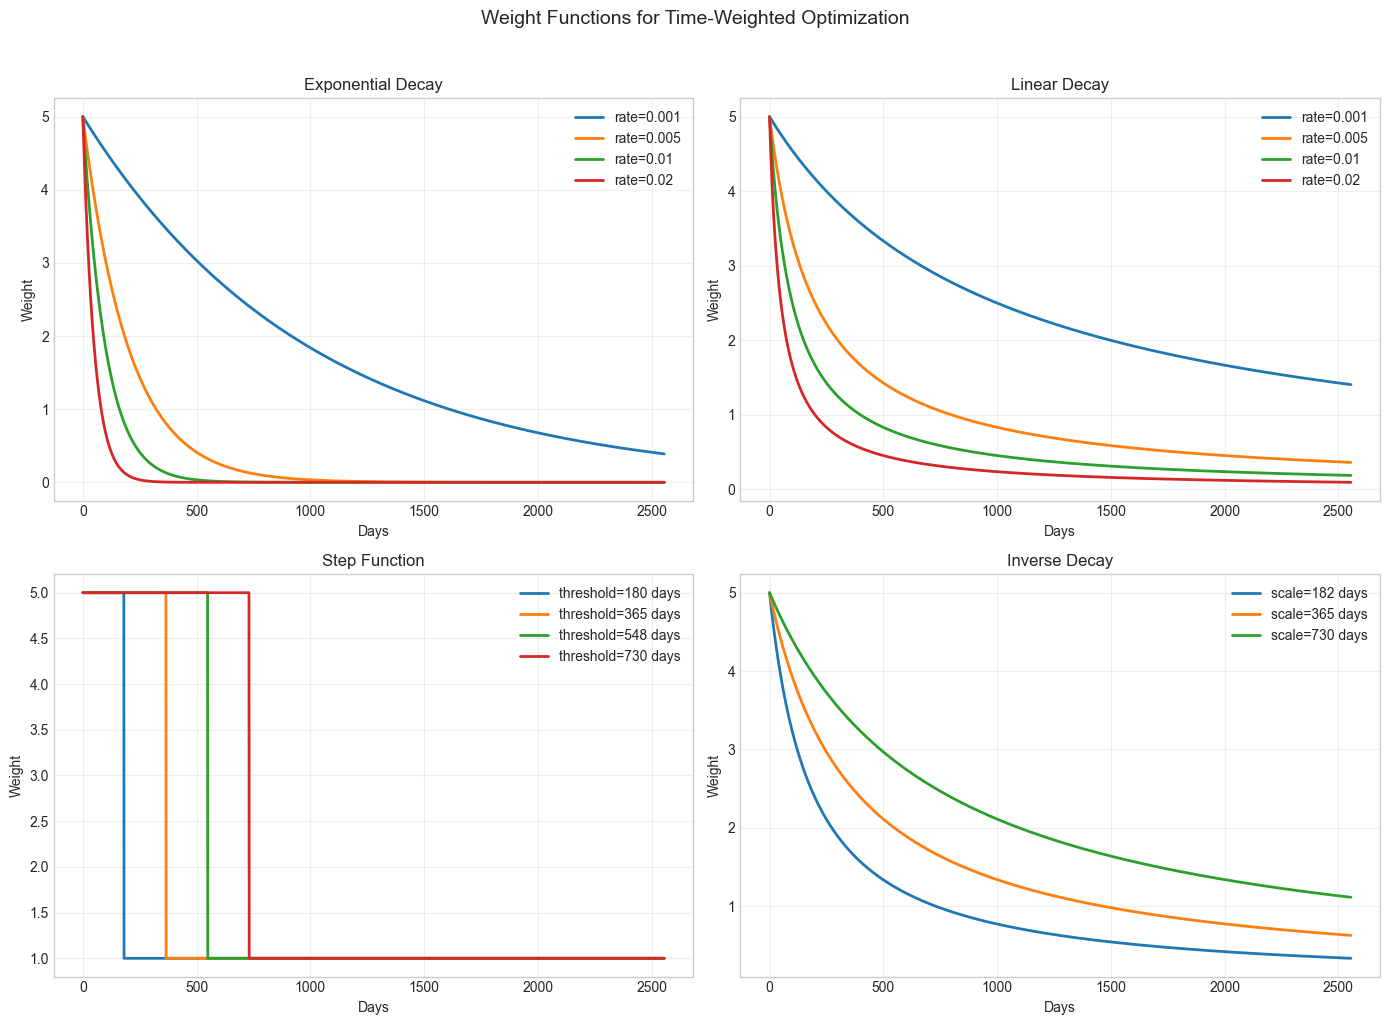

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
days = np.arange(0, 2556, 1)

ax1 = axes[0, 0]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax1.plot(days, 5.0 * np.exp(-rate * days), linewidth=2, label=f'rate={rate}')
ax1.set_title('Exponential Decay'); ax1.set_xlabel('Days'); ax1.set_ylabel('Weight'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax2.plot(days, 5.0 / (1 + rate * days), linewidth=2, label=f'rate={rate}')
ax2.set_title('Linear Decay'); ax2.set_xlabel('Days'); ax2.set_ylabel('Weight'); ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
for thresh in [180, 365, 548, 730]:
    w = np.where(days <= thresh, 5.0, 1.0)
    ax3.plot(days, w, linewidth=2, label=f'threshold={thresh} days')
ax3.set_title('Step Function'); ax3.set_xlabel('Days'); ax3.set_ylabel('Weight'); ax3.legend(); ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
for scale in [182, 365, 730]:
    ax4.plot(days, 5.0 * (1.0 / (1.0 + days / scale)), linewidth=2, label=f'scale={scale} days')
ax4.set_title('Inverse Decay'); ax4.set_xlabel('Days'); ax4.set_ylabel('Weight'); ax4.legend(); ax4.grid(True, alpha=0.3)

plt.suptitle('Weight Functions for Time-Weighted Optimization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 2: Grid Search with Exponential Weighting

In [8]:
if 'exponential' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Exponential Weighting")
    print("=" * 70)
    grid_size = len(H0_candidates) * len(k_candidates) * len(phi_candidates)
    print(f"Grid size: {len(H0_candidates)} x {len(k_candidates)} x {len(phi_candidates)} = {grid_size}")
    print(f"Weight: exponential decay, rate={decay_rate}, initial_weight={initial_weight}")
    print()

    best_params_exp = None
    best_mse_exp = 1e15

    for h0, k, phi in itertools.product(H0_candidates, k_candidates, phi_candidates):
        mse = objective_function_weighted_2017([h0, k, phi],
                                         weight_decay='exponential',
                                         decay_rate=decay_rate,
                                         initial_weight=initial_weight)
        if mse < best_mse_exp:
            best_mse_exp = mse
            best_params_exp = (h0, k, phi)
        print(f"  H0={h0:.1f}, k={k:.2f}, phi={phi:.2f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Exponential): H0={best_params_exp[0]:.1f}, k={best_params_exp[1]:.2f}, phi={best_params_exp[2]:.2f}")
    print(f"  Weighted MSE = {best_mse_exp:,.2f}")
else:
    print("Exponential results already loaded — skipping grid search.")
    best_params_exp = (H0_optimal_exp, k_optimal_exp, phi_optimal_exp)

GRID SEARCH: Exponential Weighting
Grid size: 5 x 5 x 6 = 150
Weight: exponential decay, rate=0.005, initial_weight=5.0

  H0=45.0, k=0.10, phi=0.01 -> Weighted MSE=  619,116.21
  H0=45.0, k=0.10, phi=0.03 -> Weighted MSE=  618,289.58
  H0=45.0, k=0.10, phi=0.05 -> Weighted MSE=  617,310.26
  H0=45.0, k=0.10, phi=0.10 -> Weighted MSE=  615,948.12
  H0=45.0, k=0.10, phi=0.15 -> Weighted MSE=  615,261.82
  H0=45.0, k=0.10, phi=0.20 -> Weighted MSE=  615,964.57
  H0=45.0, k=0.25, phi=0.01 -> Weighted MSE=1,157,295.34
  H0=45.0, k=0.25, phi=0.03 -> Weighted MSE=1,158,054.91
  H0=45.0, k=0.25, phi=0.05 -> Weighted MSE=1,158,305.69
  H0=45.0, k=0.25, phi=0.10 -> Weighted MSE=1,158,523.44
  H0=45.0, k=0.25, phi=0.15 -> Weighted MSE=1,156,931.51
  H0=45.0, k=0.25, phi=0.20 -> Weighted MSE=1,155,813.51
  H0=45.0, k=0.50, phi=0.01 -> Weighted MSE=1,169,301.46
  H0=45.0, k=0.50, phi=0.03 -> Weighted MSE=1,168,964.21
  H0=45.0, k=0.50, phi=0.05 -> Weighted MSE=1,168,998.40
  H0=45.0, k=0.50, phi=0

In [9]:
if 'exponential' not in saved:
    print("Fine optimization with L-BFGS-B (Exponential)...")
    result_exp = minimize(
        lambda p: objective_function_weighted_2017(p, weight_decay='exponential',
                                             decay_rate=decay_rate, initial_weight=initial_weight),
        list(best_params_exp), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    H0_optimal_exp, k_optimal_exp, phi_optimal_exp = result_exp.x
    print(f"  H0={H0_optimal_exp:.4f}, k={k_optimal_exp:.6f}, phi={phi_optimal_exp:.6f}")
    print(f"  Weighted MSE = {result_exp.fun:,.2f}")
    save_result('exponential', H0_optimal_exp, k_optimal_exp, phi_optimal_exp)
else:
    print(f"Exponential: H0={H0_optimal_exp:.4f}, k={k_optimal_exp:.6f}, phi={phi_optimal_exp:.6f}")

Fine optimization with L-BFGS-B (Exponential)...
  H0=45.0000, k=0.100000, phi=0.150000
  Weighted MSE = 615,154.76
  Saved exponential results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\2017_2023\calibration_results_humidity.json


---
## Section 3: Grid Search with Step Function Weighting

In [11]:
if 'step' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Step Function Weighting")
    print("=" * 70)
    print(f"Grid size: {len(H0_candidates)} x {len(k_candidates)} x {len(phi_candidates)} = {grid_size}")
    print(f"Weight: step (first year: {step_initial_weight}x, after: {step_later_weight}x)")
    print()

    best_params_step = None
    best_mse_step = 1e15

    for h0, k, phi in itertools.product(H0_candidates, k_candidates, phi_candidates):
        mse = objective_function_weighted_2017([h0, k, phi],
                                         weight_decay='step',
                                         initial_weight=step_initial_weight,
                                         step_later_weight=step_later_weight)
        if mse < best_mse_step:
            best_mse_step = mse
            best_params_step = (h0, k, phi)
        print(f"  H0={h0:.1f}, k={k:.2f}, phi={phi:.2f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Step): H0={best_params_step[0]:.1f}, k={best_params_step[1]:.2f}, phi={best_params_step[2]:.2f}")
    print(f"  Weighted MSE = {best_mse_step:,.2f}")
else:
    print("Step results already loaded — skipping grid search.")
    best_params_step = (H0_optimal_step, k_optimal_step, phi_optimal_step)

GRID SEARCH: Step Function Weighting
Grid size: 5 x 5 x 6 = 150
Weight: step (first year: 5.0x, after: 1.0x)

  H0=45.0, k=0.10, phi=0.01 -> Weighted MSE=  647,873.41
  H0=45.0, k=0.10, phi=0.03 -> Weighted MSE=  644,797.65
  H0=45.0, k=0.10, phi=0.05 -> Weighted MSE=  641,484.92
  H0=45.0, k=0.10, phi=0.10 -> Weighted MSE=  633,259.40
  H0=45.0, k=0.10, phi=0.15 -> Weighted MSE=  624,903.80
  H0=45.0, k=0.10, phi=0.20 -> Weighted MSE=  615,883.40
  H0=45.0, k=0.25, phi=0.01 -> Weighted MSE=  842,056.09
  H0=45.0, k=0.25, phi=0.03 -> Weighted MSE=  841,138.51
  H0=45.0, k=0.25, phi=0.05 -> Weighted MSE=  843,543.19
  H0=45.0, k=0.25, phi=0.10 -> Weighted MSE=  843,831.13
  H0=45.0, k=0.25, phi=0.15 -> Weighted MSE=  843,990.20
  H0=45.0, k=0.25, phi=0.20 -> Weighted MSE=  844,932.03
  H0=45.0, k=0.50, phi=0.01 -> Weighted MSE=  880,477.51
  H0=45.0, k=0.50, phi=0.03 -> Weighted MSE=  878,916.92
  H0=45.0, k=0.50, phi=0.05 -> Weighted MSE=  881,671.32
  H0=45.0, k=0.50, phi=0.10 -> Weig

In [12]:
if 'step' not in saved:
    print("Fine optimization with L-BFGS-B (Step)...")
    result_step = minimize(
        lambda p: objective_function_weighted_2017(p, weight_decay='step',
                                             initial_weight=step_initial_weight,
                                             step_later_weight=step_later_weight),
        list(best_params_step), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    H0_optimal_step, k_optimal_step, phi_optimal_step = result_step.x
    print(f"  H0={H0_optimal_step:.4f}, k={k_optimal_step:.6f}, phi={phi_optimal_step:.6f}")
    print(f"  Weighted MSE = {result_step.fun:,.2f}")
    save_result('step', H0_optimal_step, k_optimal_step, phi_optimal_step)
else:
    print(f"Step: H0={H0_optimal_step:.4f}, k={k_optimal_step:.6f}, phi={phi_optimal_step:.6f}")

Fine optimization with L-BFGS-B (Step)...
  H0=58.0000, k=0.250000, phi=0.150000
  Weighted MSE = 583,605.76
  Saved step results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\2017_2023\calibration_results_humidity.json


---
## Section 4: Grid Search with Inverse Decay Weighting

In [14]:
if 'inverse' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Inverse Decay Weighting")
    print("=" * 70)
    print(f"Grid size: {len(H0_candidates)} x {len(k_candidates)} x {len(phi_candidates)} = {grid_size}")
    print(f"Weight: inverse decay, scale={inverse_scale} days")
    print()

    best_params_inv = None
    best_mse_inv = 1e15

    for h0, k, phi in itertools.product(H0_candidates, k_candidates, phi_candidates):
        mse = objective_function_weighted_2017([h0, k, phi],
                                         weight_decay='inverse',
                                         initial_weight=initial_weight,
                                         inverse_scale=inverse_scale)
        if mse < best_mse_inv:
            best_mse_inv = mse
            best_params_inv = (h0, k, phi)
        print(f"  H0={h0:.1f}, k={k:.2f}, phi={phi:.2f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Inverse): H0={best_params_inv[0]:.1f}, k={best_params_inv[1]:.2f}, phi={best_params_inv[2]:.2f}")
    print(f"  Weighted MSE = {best_mse_inv:,.2f}")
else:
    print("Inverse results already loaded — skipping grid search.")
    best_params_inv = (H0_optimal_inv, k_optimal_inv, phi_optimal_inv)

GRID SEARCH: Inverse Decay Weighting
Grid size: 5 x 5 x 6 = 150
Weight: inverse decay, scale=365 days

  H0=45.0, k=0.10, phi=0.01 -> Weighted MSE=  636,660.42
  H0=45.0, k=0.10, phi=0.03 -> Weighted MSE=  633,657.62
  H0=45.0, k=0.10, phi=0.05 -> Weighted MSE=  630,418.73
  H0=45.0, k=0.10, phi=0.10 -> Weighted MSE=  622,097.96
  H0=45.0, k=0.10, phi=0.15 -> Weighted MSE=  613,272.60
  H0=45.0, k=0.10, phi=0.20 -> Weighted MSE=  603,405.67
  H0=45.0, k=0.25, phi=0.01 -> Weighted MSE=  703,544.01
  H0=45.0, k=0.25, phi=0.03 -> Weighted MSE=  702,359.19
  H0=45.0, k=0.25, phi=0.05 -> Weighted MSE=  705,083.69
  H0=45.0, k=0.25, phi=0.10 -> Weighted MSE=  705,572.68
  H0=45.0, k=0.25, phi=0.15 -> Weighted MSE=  705,403.57
  H0=45.0, k=0.25, phi=0.20 -> Weighted MSE=  706,519.25
  H0=45.0, k=0.50, phi=0.01 -> Weighted MSE=  743,221.64
  H0=45.0, k=0.50, phi=0.03 -> Weighted MSE=  742,320.48
  H0=45.0, k=0.50, phi=0.05 -> Weighted MSE=  744,901.23
  H0=45.0, k=0.50, phi=0.10 -> Weighted MS

In [15]:
if 'inverse' not in saved:
    print("Fine optimization with L-BFGS-B (Inverse)...")
    result_inv = minimize(
        lambda p: objective_function_weighted_2017(p, weight_decay='inverse',
                                             initial_weight=initial_weight,
                                             inverse_scale=inverse_scale),
        list(best_params_inv), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    H0_optimal_inv, k_optimal_inv, phi_optimal_inv = result_inv.x
    print(f"  H0={H0_optimal_inv:.4f}, k={k_optimal_inv:.6f}, phi={phi_optimal_inv:.6f}")
    print(f"  Weighted MSE = {result_inv.fun:,.2f}")
    save_result('inverse', H0_optimal_inv, k_optimal_inv, phi_optimal_inv)
else:
    print(f"Inverse: H0={H0_optimal_inv:.4f}, k={k_optimal_inv:.6f}, phi={phi_optimal_inv:.6f}")

Fine optimization with L-BFGS-B (Inverse)...
  H0=57.6562, k=0.254297, phi=0.197606
  Weighted MSE = 512,976.02
  Saved inverse results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\2017_2023\calibration_results_humidity.json


---
## Section 5: Comparison of All Weighting Methods

Compare the results from exponential, step, and inverse decay weighting, as well as unweighted optimization.

In [17]:
print("Running simulations for comparison...")

dates_default, IH_default = run_with_humidity_2017(58.0, 0.25, 0.05)
print(f"Default: H0=58, k=0.25, phi=0.05")

print("\nRunning unweighted optimization...")
result_unweighted = minimize(
    objective_function_unweighted_2017, [58.0, 0.25, 0.05],
    method='L-BFGS-B', bounds=bounds, options={'maxiter': 100, 'ftol': 1e-8}
)
H0_opt_unw, k_opt_unw, phi_opt_unw = result_unweighted.x
dates_unw, IH_unw = run_with_humidity_2017(H0_opt_unw, k_opt_unw, phi_opt_unw)
print(f"Unweighted: H0={H0_opt_unw:.2f}, k={k_opt_unw:.4f}, phi={phi_opt_unw:.4f}")

print("\nRunning exponential weighting...")
dates_exp, IH_exp = run_with_humidity_2017(H0_optimal_exp, k_optimal_exp, phi_optimal_exp)
print(f"Exponential: H0={H0_optimal_exp:.2f}, k={k_optimal_exp:.4f}, phi={phi_optimal_exp:.4f}")

print("\nRunning step function weighting...")
dates_step, IH_step = run_with_humidity_2017(H0_optimal_step, k_optimal_step, phi_optimal_step)
print(f"Step: H0={H0_optimal_step:.2f}, k={k_optimal_step:.4f}, phi={phi_optimal_step:.4f}")

print("\nRunning inverse decay weighting...")
dates_inv, IH_inv = run_with_humidity_2017(H0_optimal_inv, k_optimal_inv, phi_optimal_inv)
print(f"Inverse: H0={H0_optimal_inv:.2f}, k={k_optimal_inv:.4f}, phi={phi_optimal_inv:.4f}")

print("\nAll simulations completed!")

Running simulations for comparison...
Default: H0=58, k=0.25, phi=0.05

Running unweighted optimization...
Unweighted: H0=58.00, k=0.2500, phi=0.0500

Running exponential weighting...
Exponential: H0=45.00, k=0.1000, phi=0.1500

Running step function weighting...
Step: H0=58.00, k=0.2500, phi=0.1500

Running inverse decay weighting...
Inverse: H0=57.66, k=0.2543, phi=0.1976

All simulations completed!


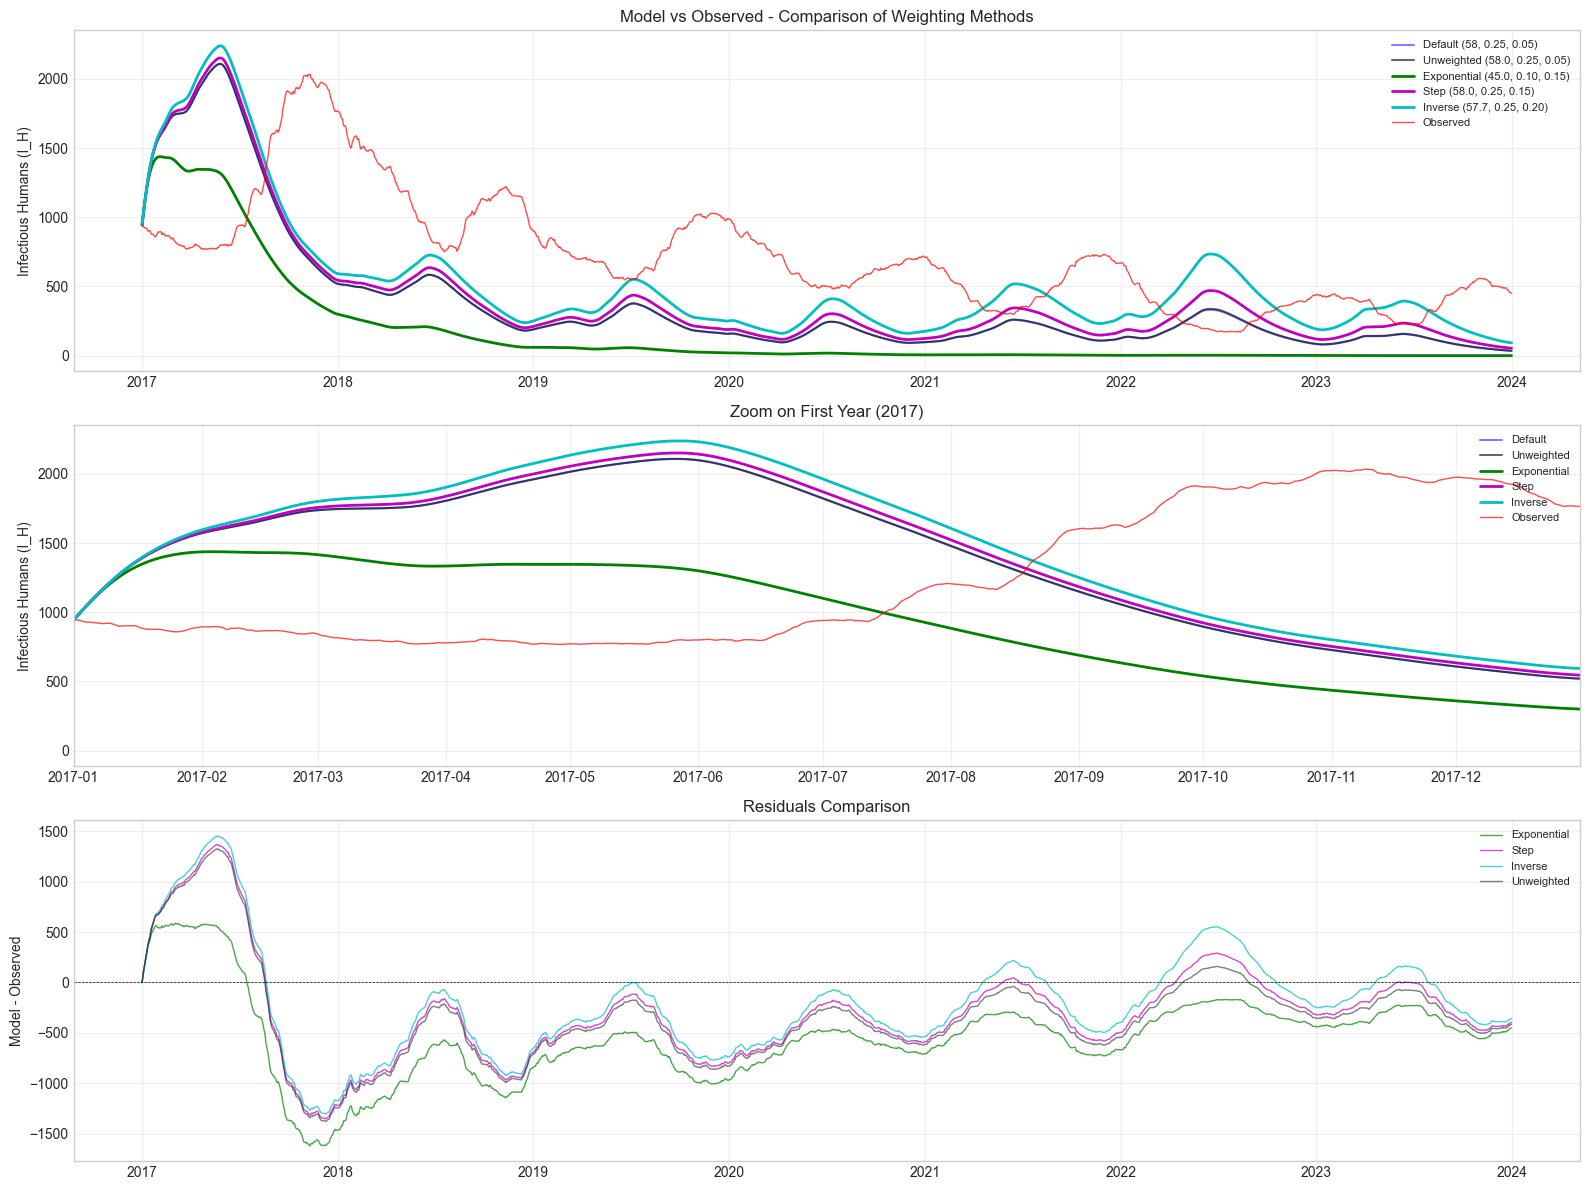

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default (58, 0.25, 0.05)')
ax1.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6, label=f'Unweighted ({H0_opt_unw:.1f}, {k_opt_unw:.2f}, {phi_opt_unw:.2f})')
ax1.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2, label=f'Exponential ({H0_optimal_exp:.1f}, {k_optimal_exp:.2f}, {phi_optimal_exp:.2f})')
ax1.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2, label=f'Step ({H0_optimal_step:.1f}, {k_optimal_step:.2f}, {phi_optimal_step:.2f})')
ax1.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2, label=f'Inverse ({H0_optimal_inv:.1f}, {k_optimal_inv:.2f}, {phi_optimal_inv:.2f})')
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)'); ax1.set_title('Model vs Observed - Comparison of Weighting Methods')
ax1.legend(loc='upper right', fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
first_year_end = pd.to_datetime('2017-12-31')
ax2.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default')
ax2.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6, label='Unweighted')
ax2.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2, label='Exponential')
ax2.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2, label='Step')
ax2.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2, label='Inverse')
ax2.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax2.set_xlim(pd.to_datetime('2017-01-01'), first_year_end)
ax2.set_ylabel('Infectious Humans (I_H)'); ax2.set_title('Zoom on First Year (2017)')
ax2.legend(loc='upper right', fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = axes[2]
obs_dates_int = rural_cases_df['date'].astype(np.int64).values
for dates_arr, IH_arr, label, color, alpha in [
    (dates_exp, IH_exp, 'Exponential', 'g', 0.7),
    (dates_step, IH_step, 'Step', 'm', 0.7),
    (dates_inv, IH_inv, 'Inverse', 'c', 0.7),
    (dates_unw, IH_unw, 'Unweighted', 'k', 0.5),
]:
    mi = interp1d(pd.to_datetime(dates_arr).astype(np.int64), IH_arr, kind='linear', fill_value='extrapolate')
    ax3.plot(rural_cases_df['date'], mi(obs_dates_int) - rural_cases_df['active_total'].values,
             '-', color=color, linewidth=1.0, alpha=alpha, label=label)
ax3.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax3.set_ylabel('Model - Observed'); ax3.set_title('Residuals Comparison')
ax3.legend(loc='upper right', fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6: Quantitative Comparison

In [20]:
def compute_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    return np.mean((mi(rural_cases_df['date'].astype(np.int64).values) - rural_cases_df['active_total'].values) ** 2)

def compute_first_year_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    mask = rural_cases_df['date'] <= pd.to_datetime('2017-12-31')
    return np.mean((mi(rural_cases_df.loc[mask, 'date'].astype(np.int64).values) - rural_cases_df.loc[mask, 'active_total'].values) ** 2)

method_results = {
    'Default':     {'dates': dates_default, 'IH': IH_default, 'H0': 58.0, 'k': 0.25, 'phi': 0.05},
    'Unweighted':  {'dates': dates_unw,     'IH': IH_unw,     'H0': H0_opt_unw, 'k': k_opt_unw, 'phi': phi_opt_unw},
    'Exponential': {'dates': dates_exp,     'IH': IH_exp,     'H0': H0_optimal_exp, 'k': k_optimal_exp, 'phi': phi_optimal_exp},
    'Step':        {'dates': dates_step,    'IH': IH_step,    'H0': H0_optimal_step, 'k': k_optimal_step, 'phi': phi_optimal_step},
    'Inverse':     {'dates': dates_inv,     'IH': IH_inv,     'H0': H0_optimal_inv, 'k': k_optimal_inv, 'phi': phi_optimal_inv},
}

print("=" * 80)
print("QUANTITATIVE COMPARISON")
print("=" * 80)
print(f"{'Method':<15} {'Overall MSE':>15} {'First Year MSE':>15} {'H0':>8} {'k':>8} {'phi':>8}")
print("-" * 80)

best_overall_method, best_overall_mse = None, 1e15
best_firstyear_method, best_firstyear_mse = None, 1e15

for method, info in method_results.items():
    overall_mse = compute_mse(info['dates'], info['IH'])
    fym = compute_first_year_mse(info['dates'], info['IH'])
    if method != 'Default' and overall_mse < best_overall_mse:
        best_overall_mse = overall_mse; best_overall_method = method
    if method != 'Default' and fym < best_firstyear_mse:
        best_firstyear_mse = fym; best_firstyear_method = method
    print(f"{method:<15} {overall_mse:>15,.2f} {fym:>15,.2f} {info['H0']:>8.2f} {info['k']:>8.4f} {info['phi']:>8.4f}")

print("=" * 80)
print(f"\nBest by overall MSE: {best_overall_method} ({best_overall_mse:,.2f})")
print(f"Best by first-year MSE: {best_firstyear_method} ({best_firstyear_mse:,.2f})")

QUANTITATIVE COMPARISON
Method              Overall MSE  First Year MSE       H0        k      phi
--------------------------------------------------------------------------------
Default              363,150.66      987,633.23    58.00   0.2500   0.0500
Unweighted           362,840.02      986,978.92    58.00   0.2500   0.0500
Exponential          490,975.20      854,433.45    45.00   0.1000   0.1500
Step                 341,983.34    1,004,134.20    58.00   0.2500   0.1500
Inverse              317,992.25    1,047,578.00    57.66   0.2543   0.1976

Best by overall MSE: Inverse (317,992.25)
Best by first-year MSE: Exponential (854,433.45)


---
## Section 7: Summary and Final Plot

In [22]:
print("=" * 80)
print("SUMMARY: WEIGHTED HUMIDITY PARAMETER CALIBRATION")
print("=" * 80)
print()
print("Problem: Model shows initial increase in I_H while data shows decrease.")
print("Solution: Time-weighted optimization to prioritize early time periods.")
print("Setup: No warm-up (2017-2023), fixed 2017 ode_models ICs, M' = 40 x N_2017.")
print()
print("Results:")
print(f"  Exponential: H0={H0_optimal_exp:.2f}, k={k_optimal_exp:.4f}, phi={phi_optimal_exp:.4f}")
print(f"  Step:        H0={H0_optimal_step:.2f}, k={k_optimal_step:.4f}, phi={phi_optimal_step:.4f}")
print(f"  Inverse:     H0={H0_optimal_inv:.2f}, k={k_optimal_inv:.4f}, phi={phi_optimal_inv:.4f}")
print(f"\nBest by overall MSE: {best_overall_method}")
print(f"Best by first-year MSE: {best_firstyear_method}")
print()
print("Next Steps:")
print("  1. Use the best-performing weighted parameters in subsequent calibrations")
print("  2. Consider adjusting decay_rate and initial_weight for further optimization")
print("  3. Validate the model fit against independent data if available")
print("=" * 80)

SUMMARY: WEIGHTED HUMIDITY PARAMETER CALIBRATION

Problem: Model shows initial increase in I_H while data shows decrease.
Solution: Time-weighted optimization to prioritize early time periods.
Setup: No warm-up (2017-2023), fixed 2017 ode_models ICs, M' = 40 x N_2017.

Results:
  Exponential: H0=45.00, k=0.1000, phi=0.1500
  Step:        H0=58.00, k=0.2500, phi=0.1500
  Inverse:     H0=57.66, k=0.2543, phi=0.1976

Best by overall MSE: Inverse
Best by first-year MSE: Exponential

Next Steps:
  1. Use the best-performing weighted parameters in subsequent calibrations
  2. Consider adjusting decay_rate and initial_weight for further optimization
  3. Validate the model fit against independent data if available


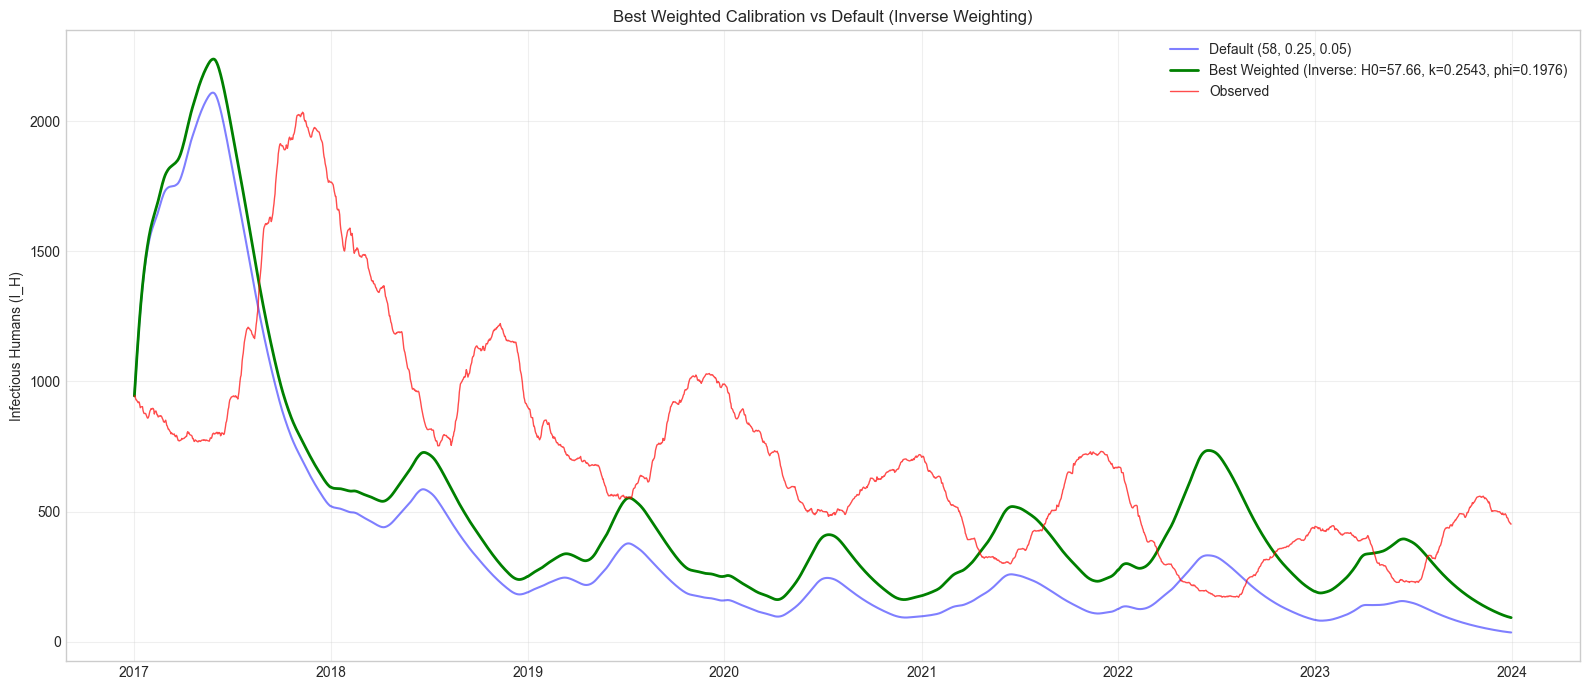

In [23]:
best_method = best_overall_method
best_info = method_results[best_method]

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default (58, 0.25, 0.05)')
ax.plot(pd.to_datetime(best_info['dates']), best_info['IH'], 'g-', linewidth=2,
        label=f'Best Weighted ({best_method}: H0={best_info["H0"]:.2f}, k={best_info["k"]:.4f}, phi={best_info["phi"]:.4f})')
ax.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax.set_ylabel('Infectious Humans (I_H)')
ax.set_title(f'Best Weighted Calibration vs Default ({best_method} Weighting)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()